#1. Imports and Seed

In [26]:
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

#To get the same results (reproducibility)
def set_seed (seed = 42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu" # To chechk if GPU is available
print ("Device: ", device)


Device:  cpu


#2. Download and Unzipping to Google Drive

In [27]:
import os  # filesystem operations (paths, folders, walking directories)
import re   # regular expressions (pattern matching on filenames)
import shutil   # high level file operations (copy, remove directories)
import zipfile
from google.colab import drive

drive.mount("/content/drive")   # mounting google drive inside Colab at /content/drive

DATA_DIR = "/content/drive/MyDrive/data/MHEALTH"   # where extracted subject files will be stored
ZIP_PATH = "/content/drive/MyDrive/data/MHEALTHDATASET.zip"   # where the dataset zip file will be saved in drive

UCI_ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00319/MHEALTHDATASET.zip"  # URL of the official MHEALTH dataset from the UCI repository


# creating folders if they don’t exist (exist_ok=True -> avoids crashing if the folder already exists)
os.makedirs(DATA_DIR, exist_ok = True)
os.makedirs("/content/drive/MyDrive/data", exist_ok = True)


# checking if the zip already exists in drive: if it exists -> skips download
# if not -> downloads it using curl    # -L -> for redirects  # -o -> output file path   # ! -> shell command, not Python
if os.path.isfile(ZIP_PATH):
  print("Zip already exists on drive:", ZIP_PATH)
else:
  print("Downloading zip to drive...")
  !curl -L "{UCI_ZIP_URL}" -o "{ZIP_PATH}"


# verifying that the file is really a zip (some parts are added beacuse of bugs. This block exists because UCI sometimes returns HTML instead of ZIP.)
with open(ZIP_PATH, "rb") as f:   # opening the file in binary mode.
    sig = f.read(4)  # reading the first 4 bytes (zip files start with a known signature)

print("Zip signature bytes:", sig)   # printing the raw signature bytes

if sig == b"PK\x03\x04":   # PK\x03\x04 is the official zip number
    print("Looks like a valid zip")  # confirming the file is actually a zip archive
else:
    print("This file is NOT a real zip") # its often an HTML error page downloaded instead of the dataset
    print("Showing the firts 200 bytes for debugging:")
    with open (ZIP_PATH, "rb") as f:
        print(f.read(200))  # printing the first 200 bytes to understand what went wrong
    raise FileNotFoundError("Downloaded file is not a zip. Try deleting it and runnign this cell again.")  # stopping execution to prevent further errors


# Extracting zip to a temporary runtime folder
TMP_DIR = "/content/mhealth_tmp"  # temporary extraction directory in Colab runtime
shutil.rmtree(TMP_DIR, ignore_errors = True)  # deleting old temp folder if it exists   # ignore_errors = True -> avoids crashing if it doesnt exist
os.makedirs(TMP_DIR, exist_ok = True)  # recreating a clean temp directory

with zipfile.ZipFile(ZIP_PATH, "r") as z:  # opening the zip file for reading
    names = z.namelist()   # getting a list of all files inside the zip
    print("\n First 40 items inside the zip:")  # printing first 40 filenames for debug and inspection
    for n in names[:40]:
        print(" -", n)
    z.extractall(TMP_DIR)  # extracts everything into the temp directory


# finding any candidate files that look like subjet files (case insensitive)
all_files = []  # this will store paths of all extracted files
for root, _, files in os.walk(TMP_DIR):  # walking through all subfolders and building full paths to every file
    for fn in files:
        all_files.append(os.path.join(root, fn))

print("\n Extracted file count:", len(all_files))  # showing how many files were extracted
print("First 20 extracted files:")   # printing sample paths for verification
for p in all_files[:20]:
    print(" -", p)



# detecting subject files using regex
pat = re.compile(r"subject\s*0*([1-9]|10)\b", re.IGNORECASE)  # extracting the subject number -> (1–10) -> (subject1, subject01, mHealth_subject05, etc.)

candidates = {}   # subject_number -> list of pahts
for p in all_files:
    base = os.path.basename(p) # extracting filename without directories
    m = pat.search(base)  # applying regex to filename
    if m:   # extracting subject number and adding file path to that subject’s list
        num = int(m.group(1))
        candidates.setdefault(num, []).append(p)


print("\n Detected subject candidates:")   # showing how many candidate files were found per subject
for k in sorted(candidates.keys()):
    print(k, "->", len(candidates[k]), "files")



# choosing the best file per subject (prefer .log, else shortest name)
chosen = {}  # final selection -> one file per subject
for num in range(1, 11):   # iterating over expected subjects -> (1–10)
    if num in candidates:
        opts = candidates[num]  # getting candidate files
        log_opts = [p for p in opts if p.lower().endswith(".log")]   # prefers .log files if any (actual sensor data)
        pick_from = log_opts if len(log_opts) > 0 else opts   # using .log files if available; otherwise fallback
        chosen[num] = sorted(pick_from, key = lambda x: len(x))[0]   # choosing the shortest filename. This avoids weird duplicates or nested paths



# copying files to Drive with standard names
missing_nums = [i for i in range(1, 11) if i not in chosen]  # detecting missing subjects

if len(missing_nums) == 0:  # if all 10 subjects were found
    for i in range(1, 11):   # copying each subject file to Drive and renaming them.
        src = chosen[i]
        dst = os.path.join(DATA_DIR, f"mHealth_subject{i}.log")
        shutil.copyfile(src, dst)
        print(f"Copied subject{i}: {os.path.basename(src)} -> {os.path.basename(dst)}")  # printing what was copied

    print("\n Final drive folder listing:")   # showing contents of the final data folder
    !ls -lah "{DATA_DIR}" | head -n 30
else:   # error handling if subjects are missing
    print("\n Could not detect these subjects:", missing_nums)
    print("Here are the files that contain the word 'subject' (debug):")
    for p in all_files:   # printing all filenames containing subject for debugging
        if "subject" in os.path.basename(p).lower():
            print(" -", p)
    raise FileNotFoundError("Could not auto detect all 10 subjects. See debug listing above.")   # stops execution


print("\n Set DATA_DIR =", DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip already exists on drive: /content/drive/MyDrive/data/MHEALTHDATASET.zip
Zip signature bytes: b'PK\x03\x04'
Looks like a valid zip

 First 40 items inside the zip:
 - MHEALTHDATASET/
 - MHEALTHDATASET/mHealth_subject1.log
 - MHEALTHDATASET/mHealth_subject10.log
 - MHEALTHDATASET/mHealth_subject2.log
 - MHEALTHDATASET/mHealth_subject3.log
 - MHEALTHDATASET/mHealth_subject4.log
 - MHEALTHDATASET/mHealth_subject5.log
 - MHEALTHDATASET/mHealth_subject6.log
 - MHEALTHDATASET/mHealth_subject7.log
 - MHEALTHDATASET/mHealth_subject8.log
 - MHEALTHDATASET/mHealth_subject9.log
 - MHEALTHDATASET/README.txt

 Extracted file count: 11
First 20 extracted files:
 - /content/mhealth_tmp/MHEALTHDATASET/mHealth_subject1.log
 - /content/mhealth_tmp/MHEALTHDATASET/mHealth_subject8.log
 - /content/mhealth_tmp/MHEALTHDATASET/mHealth_subject5.log
 - /content/mhealth_tmp/MHEALTHD

#3. Loading Raw Data

Assumption: last column = activity label.
The shapes are printed for checking

In [28]:
def load_subject(path):
    df = pd.read_csv(path, header = None, delim_whitespace = True)   # Reading the MHEALTH .log files -> have no header row and are space separated
    return df   # returns the loaded dataframe. each datafrrame contains: rows -> time samples & columns -> sensor signals + activity label (last column)

subjects_raw = {}  # an empty dictionary to store subject id
for sid in range(1, 11):  # looping through subject ids 1 to 10
    path = os.path.join(DATA_DIR, f"mHealth_subject{sid}.log") # building the file path
    df = load_subject(path)  # loading the subject's .log file into a dataframe
    subjects_raw[sid] = df  # storing the dataframe in the dictionary: Key -> subject id, Value -> raw sensor data
    print(f"subject {sid} shape:", df.shape)  # printing the rows and columns for each subject -> to check subjects and detect corrupted or missing files

print("Columns detected:", subjects_raw[1].shape[1], "(last one assumed label)")
# here I took subject 1 as reference and printed the number of columns (all subjects have the same no. of columns)

/tmp/ipython-input-1660527129.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, header = None, delim_whitespace = True)   # Reading the MHEALTH .log files -> have no header row and are space separated


subject 1 shape: (161280, 24)


/tmp/ipython-input-1660527129.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, header = None, delim_whitespace = True)   # Reading the MHEALTH .log files -> have no header row and are space separated


subject 2 shape: (130561, 24)


/tmp/ipython-input-1660527129.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, header = None, delim_whitespace = True)   # Reading the MHEALTH .log files -> have no header row and are space separated


...

subject 8 shape: (129024, 24)


/tmp/ipython-input-1660527129.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, header = None, delim_whitespace = True)   # Reading the MHEALTH .log files -> have no header row and are space separated


subject 9 shape: (135168, 24)


/tmp/ipython-input-1660527129.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, header = None, delim_whitespace = True)   # Reading the MHEALTH .log files -> have no header row and are space separated


subject 10 shape: (98304, 24)
Columns detected: 24 (last one assumed label)


#4. Inspecting Labels

Printing label counts before deciding what classes to keep.

In [29]:
sid = 1  # choosing subject1 for checking
y = subjects_raw[sid].iloc[:, -1].astype(int).values  # .iloc[:, -1] -> selecting all rows, last column only  # .values -> converting Pandas series into a NumPy array
vals, counts = np.unique(y,return_counts = True)   # counting labels for subject1:  vals -> unique label ids (1, 2, 3, …), counts -> how many times each label appears
print("Labels in subject 1:", dict(zip(vals, counts)))  # printing vals and counts as a


# doing the same for all subjects
all_labels = []   # an empty list to store label arrays from all 10 subjects
for sid in range(1, 11):
    all_labels.append(subjects_raw[sid].iloc[:, -1].astype(int).values)
all_labels = np.concatenate(all_labels)

vals, counts = np.unique(all_labels, return_counts = True)
print("All labels:", dict(zip(vals, counts)))


# data cleaning -> droping the rows that contain NaN/inf. also removing rows with label == 0 (some versions use 0 for null / no activity)
def clean_df(df, remove_label_zero = True):
    df = df.copy()

    # 1) Replacing inf with NaN, then droping NaN rows
    df.replace([np.inf, -np.inf], np.nan, inplace = True)
    before = len(df)
    df.dropna(inplace = True)
    after = len(df)

    # 2) removing label == 0
    if remove_label_zero:
        y = df.iloc[:, -1].astype(int).values
        df = df.loc[y != 0].copy()

    return df, before, after


subjects_clean = {}
for sid, df in subjects_raw.items():
  df_c, before, after = clean_df(df, remove_label_zero = True)
  subjects_clean[sid] = df_c
  print(f"Subject {sid}: rows {before} -> {after} after Nan/inf drop. final {len(df_c)} after label 0 removal")


subjects_raw = subjects_clean
print("Cleaning applied. subjects_raw now contains cleaned dataframes")

# this part is just for seeing and exploring cleaned data
sid_peek = 1  # just for subject 1
df_peek = subjects_raw[sid_peek]  # a single dataframe -> containing all cleaned samples for subject 1

print("\n=== PEEK cleaned subject", sid_peek, "===")
print("shape:", df_peek.shape)  # (number_of_samples, number_of_columns)
print("First 5 rows:")
display(df_peek.head())
print("\nLast 5 rows:")
display(df_peek.tail())

print("\nLabel counts (cleaned)")
print(df_peek.iloc[:, -1].astype(int).value_counts().sort_index().head(20))


Labels in subject 1: {np.int64(0): np.int64(126106), np.int64(1): np.int64(3072), np.int64(2): np.int64(3072), np.int64(3): np.int64(3072), np.int64(4): np.int64(3072), np.int64(5): np.int64(3072), np.int64(6): np.int64(3072), np.int64(7): np.int64(3072), np.int64(8): np.int64(3379), np.int64(9): np.int64(3072), np.int64(10): np.int64(3072), np.int64(11): np.int64(3072), np.int64(12): np.int64(1075)}
All labels: {np.int64(0): np.int64(872550), np.int64(1): np.int64(30720), np.int64(2): np.int64(30720), np.int64(3): np.int64(30720), np.int64(4): np.int64(30720), np.int64(5): np.int64(30720), np.int64(6): np.int64(28315), np.int64(7): np.int64(29441), np.int64(8): np.int64(29337), np.int64(9): np.int64(30720), np.int64(10): np.int64(30720), np.int64(11): np.int64(30720), np.int64(12): np.int64(10342)}
Subject 1: rows 161280 -> 161280 after Nan/inf drop. final 35174 after label 0 removal
Subject 2: rows 130561 -> 130561 after Nan/inf drop. final 35532 after label 0 removal
Subject 3: rows

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
6656,-9.7788,0.55690,1.19750,0.008373,-0.033490,2.6493,-9.4517,0.37683,-0.20965,-0.88931,...,-2.8439,-9.0618,1.8177,-0.058824,-0.93429,-0.34483,0.355370,-0.37003,-0.35020,1
6657,-9.7733,0.27880,0.73036,-0.025118,-0.025118,2.4157,-9.5306,0.40179,-0.20965,-0.88931,...,-2.9935,-9.2048,1.5189,-0.058824,-0.93429,-0.34483,0.719910,0.17803,0.37363,1
6658,-9.8609,0.11561,0.79988,0.025118,0.016745,2.3865,-9.5991,0.48141,-0.20037,-0.86867,...,-2.8846,-9.1945,1.5507,-0.058824,-0.93429,-0.34483,0.355370,-0.37003,-0.35020,1
6659,-9.7409,0.17652,0.88957,0.180010,0.129770,2.3758,-9.5997,0.42919,-0.20037,-0.86867,...,-2.9245,-9.1746,1.5413,-0.078431,-0.93429,-0.34052,0.357180,-0.18858,-0.35198,1
6660,-9.7821,0.21637,0.90368,0.092098,0.046049,2.3239,-9.5406,0.40038,-0.20037,-0.86867,...,-2.8963,-9.2039,1.6127,-0.078431,-0.93429,-0.34052,-0.001887,-0.18867,-0.72017,1



Last 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
160251,-7.8711,0.62612,-2.8068,0.037677,0.004186,-1.1274,-7.2045,-3.62150,-1.4026,-1.2420,...,-2.3478,-9.4027,-1.27220,-1.1020,-0.47433,-0.38362,3.05160,-18.001,35.981,5
160252,-7.2748,1.11390,-3.5103,-0.246990,-0.196760,-1.3928,-5.8547,-3.29620,-1.4026,-1.2420,...,-1.9978,-9.4592,-0.92088,-1.1020,-0.47433,-0.38362,2.17060,-16.337,38.113,5
160253,-7.5005,1.28830,-1.9893,-0.138150,-0.100470,-1.1938,-5.8499,-3.80440,-1.4249,-1.1276,...,-1.9755,-8.8985,-0.85118,-1.1020,-0.47433,-0.38362,0.91794,-15.926,41.694,5
160254,-7.0947,1.70440,-2.7834,-0.092098,-0.050235,-1.9781,-6.1079,-1.87730,-1.4249,-1.1276,...,-2.2332,-8.8793,-0.93355,-1.1020,-0.47433,-0.38362,-0.12432,-12.432,45.248,5
160255,-7.2785,2.31010,-1.9289,-0.066981,-0.037677,-1.7048,-5.8298,-0.79812,-1.4249,-1.1276,...,-1.7247,-8.1280,-0.80223,-1.1373,-0.38193,-0.37069,-2.09870,-12.387,47.735,5



Label counts (cleaned)
23
1     3072
2     3072
3     3072
4     3072
5     3072
6     3072
7     3072
8     3379
9     3072
10    3072
11    3072
12    1075
Name: count, dtype: int64


#5. Choosing relevant activities (subset)


In [30]:
# defining a dictionary mapping numeric activity labels from MHEALTH to names -> only a subset is chosen
label_to_name = {
    1: "standing",
    2: "sitting",
    3: "lying",
    4: "walking",
    5: "stairs",
    9: "cycling",
    10: "jogging",
}

kept_labels = sorted(label_to_name.keys())  # sorting the selected lables numerically
print("Keeping labels:", kept_labels)
print("Names:", [label_to_name[k] for k in kept_labels])  # producing a readable list

# this function returns a filtered dataframe with unwanted activities removed
def filter_labels(df, kept):  # 2 inputs
    y = df.iloc[:, -1].astype(int).values  # choosing the last column (activity labels), converting them to integeres, and to a NumPy array
    mask = np.isin(y, kept)  # creating a boolian mask
    return df.loc[mask].copy()  # kepping only the rows where mask == True

subjects = {}   # new dictionary for filtered data. structurs: subject_id -> filtered dataframe
for sid, df in subjects_raw.items():   # sid -> subject ID, df -> raw subject dataframe
    df_f = filter_labels(df, kept_labels)  # removing the rows whose activity label is not in kept_labels using the fuction
    subjects[sid] = df_f   # saving filtered dataframe for that subject
    print(f"subject{sid}: before {df.shape} -> after {df_f.shape}")  # showing how many rows were removed

Keeping labels: [1, 2, 3, 4, 5, 9, 10]
Names: ['standing', 'sitting', 'lying', 'walking', 'stairs', 'cycling', 'jogging']
subject1: before (35174, 24) -> after (21504, 24)
subject2: before (35532, 24) -> after (21504, 24)
subject3: before (35380, 24) -> after (21504, 24)
subject4: before (35328, 24) -> after (21504, 24)
subject5: before (33947, 24) -> after (21504, 24)
subject6: before (32205, 24) -> after (21504, 24)
subject7: before (34253, 24) -> after (21504, 24)
subject8: before (33332, 24) -> after (21504, 24)
subject9: before (34354, 24) -> after (21504, 24)
subject10: before (33690, 24) -> after (21504, 24)


#6. Windowing (Sliding Windows)

turning the continous signals into fixed size windod.

label per window = majority label in that window

In [31]:
SAMPLE_RATE = 50

def make_windows(X, y, window_seconds = 3, overlap = 0.5, sample_rate = SAMPLE_RATE):   # X -> sensor data (time * features) / y -> labels (synchronized with X)
    window_len = int(window_seconds * sample_rate)   # converting time into number of samples
    step = int (window_len * (1 - overlap))   # determining how far the window moves each time (how many samples)
    if step < 1:  # Preventing infinite loops
        step = 1

    Xw, yw = [], []   # empty lists for windowed sensor data and labels
    for start in range(0, len(X)-window_len + 1, step):  # creating fixed length windows and iterating over valid window start indices
    # while ensuring no partial windows at the end
        end = start + window_len
        x_win = X[start:end]   # taking a slice of sensor data
        y_win = y[start:end]   # labels for the same time interval -> one label per sample

        labels, counts = np.unique(y_win, return_counts = True) # counting how many times each label appears and
        maj = labels[np.argmax(counts)]    # picking the most repeated label for the whole window

        Xw.append(x_win) # storing the sensor window and
        yw.append(maj)   # it corresponding label

    return np.array(Xw, dtype = np.float32), np.array(yw, dtype = np.int64)   # converting the lists to NumPy arrays
    # float32 -> efficient for ML / PyTorch
    # int64 -> required for classification losses (for example CrossEntropy)


# test on subject 1
df1 = subjects[1]  # filtered dataframe for subject 1
X1 = df1.iloc[:, :-1].values   # all sensor columns except the last
y1 = df1.iloc[:, -1].astype(int).values  # extracting activity labels as integers
Xw1, yw1 = make_windows(X1, y1, window_seconds = 3, overlap = 0.5)  # applying the fi=unction for segmenting
print("Windows subject 1:", Xw1.shape, yw1.shape, "unique labels:", np.unique(yw1))   # number of windows, correct shapes (no. of time samples per window, features), and which labels are present


Windows subject 1: (285, 150, 23) (285,) unique labels: [ 1  2  3  4  5  9 10]


#7. Subject-Independant Split

Train: 1 to 7

Validation: 8

Test: 9 & 10

In [32]:
# splitting the data
train_subjects = [1,2,3,4,5,6,7]
val_subjects = [8]
test_subjects = [9,10]

# this function builds sliding windows for the subjects
def build_windows_for_subjects(subject_ids, window_seconds = 3, overlap = 0.5):
    X_all, y_all = [], []   # these will hold windowed sensor data and labels from all subjects
    for sid in subject_ids:
        df = subjects[sid]  # the filtered DataFrame for that subject
        X = df.iloc[:, :-1].values  # selecting all columns except the last
        y = df.iloc[:, -1].astype(int).values  # selecting the last column (labels) and converting them into integeres
        Xw, yw = make_windows(X, y, window_seconds, overlap)  # applying the sliding window function (defined earlier) -> windowing is done independently per subject
        X_all.append(Xw)  # appending each subject’s windowed data to the lists
        y_all.append(yw)  # appending each subject’s windowed label to the lists
    return np.concatenate(X_all, axis = 0), np.concatenate(y_all, axis = 0)  # concatenating across subjects  # axis=0 -> combines more rows, keeps columns/features the same.


WINDOW_SECONDS = 3
OVERLAP = 0.5

# applying the function to created subsets of data
Xtr, ytr = build_windows_for_subjects(train_subjects, WINDOW_SECONDS, OVERLAP)
Xva, yva = build_windows_for_subjects(val_subjects, WINDOW_SECONDS, OVERLAP)
Xte, yte = build_windows_for_subjects(test_subjects, WINDOW_SECONDS, OVERLAP)

print("Train:", Xtr.shape, ytr.shape)
print("Val:", Xva.shape, yva.shape)
print("Test:", Xte.shape, yte.shape)


Train: (1995, 150, 23) (1995,)
Val: (285, 150, 23) (285,)
Test: (570, 150, 23) (570,)


#8. Normalizing the features

Very impportant for avoiding data leakage

In [33]:
# This function defines a function to compute feature wise normalization parameters -> X -> windowed sensor data
# shape of X should be -> (num_windows, window_len, num_features)
def compute_norm_stats(X):
    mean = X.reshape(-1, X.shape[-1]).mean(axis = 0)  # X.shape[-1] -> number of sensor features, X.reshape(-1, X.shape[-1]) -> flattens windows * time into one dimension
    # new shape -> (num_windows * window_len, num_features), .mean(axis=0) -> computes one mean per feature, Result shape -> (num_features,)
    std = X.reshape(-1, X.shape[-1]).std(axis = 0) + 1e-8   # same flattening logic as above, .std(axis=0) -> computes feature wise standard deviation
    # + 1e-8 -> Numerical stability, preventing division by zero for constant features
    return mean, std


# this funcction normalizes data using precomputed stats (z-score normalization)
def apply_norm(X, mean, std):
    return (X-mean)/std


mean_tr, std_tr = compute_norm_stats(Xtr)  # computing stats on training data


# normalizing training, validation, and test data
Xtr = apply_norm(Xtr, mean_tr, std_tr)
Xva = apply_norm(Xva, mean_tr, std_tr)
Xte = apply_norm(Xte, mean_tr, std_tr)

# just for checking
print("Normalized train mean (approximately 0):", Xtr.mean())
print("Normalized train std (approximately 1):", Xtr.std())


Normalized train mean (approximately 0): 2.6964367e-06
Normalized train std (approximately 1): 1.0000992


#9. Remapping the labels to numeric values

This is better for PyTorch

In [34]:
label_list = kept_labels
# since ML libraries expect labels in [0, …, K-1], this creates a dictionary that maps: original_label -> class_index
label_to_idx = {lab:i for i, lab in enumerate(label_list)}
# mapping class indices to readable names: class_index -> activity_name
idx_to_name = {label_to_idx[lab]: label_to_name[lab] for lab in label_list}

print(label_list)
print(label_to_idx)
print(idx_to_name)


# This function converts labels into 0…K−1. Input: y -> array-like of labels
def remap(y):
      y = np.array(y, dtype = np.int64)  # converting input to NumPy array
      # avoiding remap again, if labels are already in [0..K-1] -> This was an error (KeyError 0) when I reran only this cell)
      # checking wethere: minimum label ≥ 0 and maximum label < number of classes -> if true: Labels are already remapped and function returns immediately
      if y.min() >= 0 and y.max()< len(label_list):
        return y

      # Otherwise, remapping from original dataset labels -> 0..K-1
      return np.array([label_to_idx[int(v)] for v in y], dtype = np.int64)

# applying remapping to training, validation, and test labels -> all labels will be in [0 … n_classes-1]
ytr = remap(ytr)
yva = remap(yva)
yte = remap(yte)


n_classes = len(label_list)  # counting how many activity classes exist
n_features = Xtr.shape[-1]   # no. of input features

print("n_classes:", n_classes)
print("n_features:", n_features)
print("Classes:", idx_to_name)  # showing readable mapping of class indices -> activity names
print("ytr unitque:", np.unique(ytr))


[1, 2, 3, 4, 5, 9, 10]
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 9: 5, 10: 6}
{0: 'standing', 1: 'sitting', 2: 'lying', 3: 'walking', 4: 'stairs', 5: 'cycling', 6: 'jogging'}
n_classes: 7
n_features: 23
Classes: {0: 'standing', 1: 'sitting', 2: 'lying', 3: 'walking', 4: 'stairs', 5: 'cycling', 6: 'jogging'}
ytr unitque: [0 1 2 3 4 5 6]


#10. Dataset & DataLoaders

In [35]:
# defining a custom PyTorch dataset class for HAR windows -> from torch.utils.data.Dataset
class HARWindowsDataset(Dataset):
    # This function is the constructor of the dataset. Receives: X -> input data (sensor windows), y -> corresponding labels
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype = torch.float32)  # converting X into a PyTorch tensor. Using float32 cuz neural networks expect floating point inputs
        self.y = torch.tensor(y, dtype = torch.long)  # converting y into a PyTorch tensor. Using long cuz classification loss functions (like cross entropy loss) require integer class labels

    # This function defines how many samples are in the dataset
    def __len__(self):
        return len(self.y)  # returning the number of labels -> the number of data samples

    # This function defines how to retrieve one sample given an index
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # returning the input window at index idx and its corresponding label
        # this is what the DataLoader fetches during training


BATCH_SIZE = 128

train_loader = DataLoader(HARWindowsDataset(Xtr, ytr), batch_size = BATCH_SIZE, shuffle = True)  # creating a DataLoader for the training set
# shuffle = True -> randomizing data order each epoch -> important for training
val_loader = DataLoader(HARWindowsDataset(Xva, yva), batch_size = BATCH_SIZE, shuffle = False)  # the same for validation set. shuffle = False -> ensuring consistent evaluation
test_loader = DataLoader(HARWindowsDataset(Xte, yte), batch_size = BATCH_SIZE, shuffle = False) # # the same for test set. shuffle = False -> keeping the results reproducible


#11. Model Tuning: 1 layer vs. 2 layer CNN

This helps for tuning model depth

In [36]:
# defining a small 1D CNN -> from nn.Module
class SmallCNN1(nn.Module):
    # this function is the constructor of the model  # n_features -> no. of input channels (sensor features), n_classes -> no. of output classes for classification
    def __init__(self, n_features, n_classes):
        super().__init__()   # initializing the parent nn.Module class
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size = 7, padding = 3)  # first 1D convolutional layer.
        # input channels -> n_features, output channels -> 32 feature maps, kernel size 7 -> capturing temporal patterns, padding 3 -> the time dimension unchanged
        self.bn1 = nn.BatchNorm1d(32)  # applying batch normalization to the 32 convolutional channels -> stabilizing and accelerating training
        self.fc = nn.Linear(32, n_classes)  # fully connected layer mapping 32 features to class scores


    # this function defines how data flows through the network
    def forward(self, x):
        # x: (batch size,time steps,features) -> but Conv1d expects -> (batch size, features, time steps)
        x = x.transpose(1, 2)  # swapping time and feature dimensions to match Conv1d format
        x = F.relu(self.bn1(self.conv1(x)))  # applying convolution -> batch normalization -> ReLU activation. extracting temporal features from the signal
        x = x.mean(dim = 2)  # global average pooling over the time dimension. reducing (B, 32, T) to (B, 32) -> making the model invariant to window length
        return self.fc(x)  # producing final class logits



# defining a deeper CNN with two convolutional layers
class SmallCNN2(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size = 7, padding = 3)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size = 5, padding = 2)  # second convolutional layer -> increasing channels from 32 to 64.
        # kernel size 5 captures better temporal patterns
        self.bn2 = nn.BatchNorm1d(64)   # Batch normalization for the second convolution
        self.fc = nn.Linear(64, n_classes)  # fully connected layer mapping 64 features to output classes


    def forward(self, x):
         x = x.transpose(1, 2)
         x = F.relu(self.bn1(self.conv1(x)))
         x = F.relu(self.bn2(self.conv2(x)))  # same but for the second layer -> learning higher level temporal features
         x = x.mean(dim = 2)
         return self.fc(x)


#12. Training and Evaluation Helpers

In [37]:
def train_one_epoch(model, loader, optimizer):
    model.train()   # setting the model to training mode -> enabling behaviors like dropout and batch-norm updates
    total_loss = 0.0   # accumulator for the total training loss over the epoch
    for Xb, yb in loader:   # iterating over batches provided by the DataLoader
        Xb, yb = Xb.to(device), yb.to(device)   # moving data to the selected device (CPU or GPU)

        optimizer.zero_grad()   # clearing gradients from the previous optimization step
        logits = model(Xb)   # forward pass -> computing raw class scores (logits)
        loss = F.cross_entropy(logits, yb)  # computing the cross-entropy loss for multiclass classification -> it combines LogSoftmax and NLLLoss internally.
        loss.backward()   # backpropagating the loss to compute gradients
        optimizer.step()   # updating model parameters using the optimizer

        total_loss += loss.item() * len(yb)   # accumulating the batch loss weighted by batch size. this allows correct averaging over the full dataset
    return total_loss / len(loader.dataset)   # returning the average loss per sample for the epoch



@torch.no_grad()  # disabling gradient tracking to reduce memory usage and speed up evaluation
def evaluate(model, loader):
    model.eval()   # setting the model to evaluation mode -> disabling dropout and freezing batch-norm statistics
    y_true, y_pred = [], []  # empty lists to store labels and predictions
    for Xb, yb in loader:  # iterating over validation or test batches
        Xb = Xb.to(device)  # moving input data to the device -> labels stay on CPU for metric computation
        logits = model(Xb)  # forward pass to compute logits
        pred = torch.argmax(logits, dim = 1).cpu().numpy()  # selecting the class with the highest score for each sample and moving predictions to CPU and converting to NumPy.
        # logits shape -> (batch_size, n_classes)  # dim = 1 -> look across columns (the class scores) for each row/sample

        # storing true labels and predictions for all batches
        y_true.append(yb.numpy())
        y_pred.append(pred)

    # flattening batch results into single arrays
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = accuracy_score(y_true, y_pred)   # computing classification accuracy
    f1 = f1_score(y_true, y_pred, average = "macro")  # computing macro-averaged F1 score -> it treats all classes equally (important for class imbalance)
    return acc, f1, y_true, y_pred



# this function trains a model for multiple epochs and selects the best version
def fit(model, train_loader, val_loader, lr = 1e-3, epochs = 10):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr = lr)  # initializing the Adam optimizer with the given learning rate

    # variables to track the best validation accuracy and model weights
    best_val = -1
    best_state = None

    for ep in range(1, epochs+1):  # training loop over epochs
        loss = train_one_epoch(model, train_loader, opt)  # training the model for one epoch and getting training loss using the written function
        val_acc, val_f1, _, _ = evaluate(model, val_loader)   # evaluating the model on the validation set
        print(f"Epoch {ep:02d} | loss = {loss:.4f} | val_acc = {val_acc:.4f} | val_f1 = {val_f1:.4f}")  # printing training loss and validation metrics

        # keeping best model by validation accuracy
        if  val_acc > best_val:  # checking if current model outperforms previous best
            best_val = val_acc   # updating best validation accuracy
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}   # saving a deep copy of the model weights and moving them to CPU to avoid GPU memory issues
            # detach() -> remove it from the computation graph (so PyTorch wont track gradients)

    # restoring the best performing model
    if best_state is not None:
        model.load_state_dict(best_state)
    return model  # returning the trained model with optimal validation performance


#13. Baseline (Single-Shot Training)

In [38]:
baseline = SmallCNN1(n_features, n_classes)   # the baseline model using the SmallCNN1 architecture
baseline = fit(baseline, train_loader, val_loader, lr = 1e-3, epochs = 10)  # training the baseline model -> returning the model with the best validation accuracy

test_acc, test_f1, y_true, y_pred = evaluate(baseline, test_loader)  # evaluating the trained baseline model on the held out test set
print("Baseline test acc:", test_acc)
print("Baseline test f1:", test_f1)

print(classification_report(y_true, y_pred, target_names = [idx_to_name[i] for i in range(n_classes)])) # printing a detailed per class evaluation report while mapping numeric class indices to readable activity names
# precision, recall, F1-score, support (number of samples per class)


print("=== Upper Bound / Joint Training Baseline (offline) ===")
baseline2 = SmallCNN2(n_features, n_classes)
baseline2 = fit(baseline2, train_loader, val_loader, lr = 1e-3, epochs = 10)
test_acc2, test_f12, y_true, y_pred2 = evaluate(baseline2, test_loader)
print("Baseline2 test acc:", test_acc2)
print("Baseline2 test f1:", test_f12)

print(classification_report(y_true, y_pred2, target_names = [idx_to_name[i] for i in range(n_classes)]))

# since the resulats for baseline were extremly good I put this sanity check
print(np.sum(y_true != y_pred))
# confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_true, y_pred))


Epoch 01 | loss = 1.6595 | val_acc = 0.3474 | val_f1 = 0.2525
Epoch 02 | loss = 1.2590 | val_acc = 0.5649 | val_f1 = 0.4939
Epoch 03 | loss = 1.0524 | val_acc = 0.5684 | val_f1 = 0.5205
Epoch 04 | loss = 0.8939 | val_acc = 0.5719 | val_f1 = 0.5247
Epoch 05 | loss = 0.7598 | val_acc = 0.5789 | val_f1 = 0.5270
Epoch 06 | loss = 0.6479 | val_acc = 0.6526 | val_f1 = 0.5784
Epoch 07 | loss = 0.5543 | val_acc = 0.6877 | val_f1 = 0.6023
Epoch 08 | loss = 0.4838 | val_acc = 0.6982 | val_f1 = 0.6073
Epoch 09 | loss = 0.4239 | val_acc = 0.7053 | val_f1 = 0.6179
Epoch 10 | loss = 0.3703 | val_acc = 0.7509 | val_f1 = 0.6909
Baseline test acc: 0.9912280701754386
Baseline test f1: 0.9912120262401946
              precision    recall  f1-score   support

    standing       0.99      1.00      0.99        81
     sitting       1.00      1.00      1.00        82
       lying       0.99      0.99      0.99        82
     walking       1.00      0.98      0.99        82
      stairs       1.00      0.97 

#14. Continual Learning

defining phases -> incremental classes over time -> basic activities first, then new ones

In [39]:
name_to_idx = {idx_to_name[i]:i for i in range(n_classes)}  # creating a dictionary that maps class names to numeric indices
# idx_to_name[i] gives the class name for index i -> converting readable labels into integers
print("name_to_idx:", name_to_idx)

# defining groups of activities organized into sequential phases
phases = [
    ["standing", "sitting", "walking"],  # phase 1
    ["lying"],                           # phase 2
    ["cycling"],                         # phase 3
    ["jogging"],                         # phase 4
    ["stairs"],                          # phase 5
]

phases_idx = [[name_to_idx[n] for n in ph] for ph in phases]  # converting each phase from class names to class indices -> results in a list of lists of integers
print("phases_idx:", phases_idx)

def filter_by_classes(X, y, allowed):  # this is a helper function to filter dataset by selected class indices. allowed -> a list of class indices to keep
    mask = np.isin(y, allowed)  # creating a boolean mask -> True for samples whose label is in allowed
    return X[mask], y[mask]  # returning filtered input data and labels


name_to_idx: {'standing': 0, 'sitting': 1, 'lying': 2, 'walking': 3, 'stairs': 4, 'cycling': 5, 'jogging': 6}
phases_idx: [[0, 1, 3], [2], [5], [6], [4]]


#15. Rehearsal Memory Buffer

storing up to m_per_class windows per class

In [40]:
# defining a memory buffer to store a limited number of past samples -> to reduce forgetting
class MemoryBuffer:

    # constructor of the memory buffer -> m_per_class -> max number of stored samples per class
    def __init__(self, m_per_class = 50):
        self.m_per_class = m_per_class  # storing per class memory budget
        self.data = {}  # dictionary to hold memory samples. Key -> class index, Value -> list of  cls (input, label) tuples

    # this function adds samples to the memory buffer
    def add_examples(self, X, y):
        # adding class by class
        for cls in np.unique(y):   # iterating over each unique class present in y
            idxs = np.where(y == cls)[0]  # finding indices of samples belonging to class cls
            # copying and shuffling indices to avoid ordering bias
            idxs = idxs.copy()
            np.random.shuffle(idxs)

            # initializing memory list for a new class if not already present
            if cls not in self.data:
                self.data[cls] = []

            for i in idxs:  # iterating over shuffled sample indices for the class
                if len(self.data[cls]) < self.m_per_class:   # checking if memory for this class is not yet full
                    self.data[cls].append((X[i], int(y[i])))  # storing the sample and its label in memory -> Label is changed to int
                else:
                    break  # stopping to add samples when the perclass memory limit is reached


    # this function returns all stored memory samples -> to replay old data during training
    def sample_all(self):
        X_list, y_list = [], []  # empty lists to accumulate inputs and labels
        for cls, items in self.data.items():  # iterating over all classes stored in memory
            for x_i, y_i in items:  # iterating over samples of each class
                # adding samples and labels to output lists
                X_list.append(x_i)
                y_list.append(y_i)

        # in case of having empty memory buffer
        if len(X_list) == 0:
            return None, None
        return np.stack(X_list).astype(np.float32), np.array(y_list).astype(np.int64)  # stacking samples into a NumPy array -> this ensures correct data types for PyTorch


    # this function defines how many samples are currently stored in memory
    def __len__(self):
        return sum(len(v) for v in self.data.values())  # returning the total number of stored samples across all classes


#16. Continual Learning Loop

naive vs. rehearsal, forgetting metric -> this runs phase by phase and records acc/f1 on seen classes and forgetting (how much old classes drop)

In [41]:
# evaluating the model only on classes that have been seen -> to avoid penalizing the model for unseen classes
def evaluate_on_seen(model, X_test, y_test, seen_classes):
    Xs, ys = filter_by_classes(X_test, y_test, seen_classes)  # filtering the test set to keep only samples belonging to seen_classes
    loader = DataLoader(HARWindowsDataset(Xs, ys), batch_size = 256, shuffle = False)  # creating a DataLoader for the filtered test set -> no gradients are computed
    acc, f1, _, _ = evaluate(model, loader)   # calling the evaluation function
    return acc, f1   # returning only accuracy and macro-F1 score



# Main continual learning loop: model_class -> model architecture, strategy -> "naive" (no memory, just sequential learning) or "rehearsal" (with a memory buffer),
# m_per_class -> memory size per class (used for rehearsal), epochs_per_phase -> no. of training epochs per phase
def run_continual(model_class, strategy = "naive", m_per_class = 50, lr = 1e-3, epochs_per_phase = 5):
    model = model_class(n_features, n_classes).to(device)  # instantiating the model and moving it to CPU/GPU
    buffer = MemoryBuffer(m_per_class = m_per_class) if strategy == "rehearsal" else None   # initializing replay memory buffer only if rehearsal strategy is used

    seen = []  # list of all classes encountered so far
    best_old_acc = {}  # the best historical accuracy per class -> to compute forgetting
    rows = []  # results for each phase -> to be converted into a dataframe


    for phase_id, new_classes in enumerate(phases_idx, start = 1):  # iterating over phases -> new_classes -> contains class indices introduced in the current phase
        seen = sorted(list(set(seen + new_classes)))  # updating the list of seen classes. it ensures uniqueness and sorted order

        X_new, y_new = filter_by_classes(Xtr, ytr, new_classes)   # selecting training samples only from newly introduced classes

        # building phase training set depending on strategy
        if strategy == "rehearsal":  # checking whether replay memory should be used
            X_mem, y_mem = buffer.sample_all()   # retrieving all stored memory samples
            if X_mem is None:   # if the buffer empty, it goes back to using only new data -> behaving like naive
                X_phase, y_phase = X_new, y_new
            else:   # if it's not empty, it mixes new data with replayed memory samples
                X_phase = np.concatenate([X_new, X_mem], axis = 0)
                y_phase = np.concatenate([y_new, y_mem], axis = 0)
        else:  # in case of naive strategy -> training only on new classes -> old knowledge is ignored -> catastrophic forgetting risk
            X_phase, y_phase = X_new, y_new


        # creating a training DataLoader for the current phase -> shuffling improves generalization
        train_loader_phase = DataLoader(HARWindowsDataset(X_phase, y_phase), batch_size = 128, shuffle = True)

        Xv_seen, yv_seen = filter_by_classes(Xva, yva, seen)  # filtering validation data to include only seen classes
        # validation DataLoader for seen classes only
        val_loader_seen = DataLoader(HARWindowsDataset(Xv_seen, yv_seen), batch_size = 256, shuffle = False)

        opt = torch.optim.Adam(model.parameters(), lr = lr)  # initializing a fresh Adam optimizer for the current phase (it is reinitialized each phase) -> to avoid optimizer state bias

        # training within a phase
        for ep in range(1, epochs_per_phase + 1):  # running multiple epochs for the current phase
            loss = train_one_epoch(model, train_loader_phase, opt)  # training the model for one epoch
            val_acc, _, _, _ = evaluate(model, val_loader_seen)  # evaluating validation accuracy on seen classes
            print(f"[{strategy}] Phase {phase_id} Ep {ep} | loss = {loss:.4f} | val_acc_seen = {val_acc:.4f}")  # logging training progress

        # test on seen classes
        test_acc_seen, test_f1_seen = evaluate_on_seen(model, Xva, yva, seen)  # evaluating final model performance on seen classes only ->
        # using validation set for phase by phase reporting -> avoids test leakage


        # forgetting computation -> how much knowledge did the model lose over time? -> forgetting = best past performance − current performance -> averaged across classes
        forgetting_vals = []  # empty list to accumulate forgetting values per class
        # this loop evaluates each seen class individually
        for cls in seen:   # iterating over each seen class
            Xc, yc = filter_by_classes(Xva, yva, [cls])  # extracting test samples for a single class
            loader_c = DataLoader(HARWindowsDataset(Xc, yc), batch_size = 256, shuffle = False)  # DataLoader for class evaluation
            acc_c, _, _, _ = evaluate(model, loader_c)  # computing accuracy for the current class

            # for each class: storing the best accuracy ever achieved and comparing current accuracy to that best value
            if cls not in best_old_acc:  # initializing best accuracy for new classes
                best_old_acc[cls] = acc_c
            else:   # updating best accuracy and computing forgetting as performance drop
                best_old_acc[cls] = max(best_old_acc[cls], acc_c)
                forgetting_vals.append(best_old_acc[cls] - acc_c)

        forgetting_mean = float(np.mean(forgetting_vals)) if len(forgetting_vals) > 0 else 0.0  # computing average forgetting across seen classes


        # storing metrics of the phase for later analysis
        rows.append({"strategy": strategy, "phase": phase_id, "seen_classes": seen.copy(), "test_acc_seen": test_acc_seen, "test_f1_seen": test_f1_seen,
                     "forgetting_mean": forgetting_mean, "buffer_size": len(buffer) if buffer is not None else 0})


        # update buffer with samples from new classes (after training)
        if strategy =="rehearsal":   # only applies to rehearsal strategy
            buffer.add_examples(X_new, y_new)   # adding samples from newly learned classes to memory
            print("Buffer size now:", len(buffer))   # logging memory growth

        print(f"==> Phase {phase_id} done | acc_seen = {test_acc_seen:.4f} | forgetting = {forgetting_mean:.4f}\n")  # a summary of the completed phase


        # final test evaluation -> only onec, after all phases (this was a bug)
        final_seen = seen   # by the end this should be all used classes
        final_test_acc, final_test_f1 = evaluate_on_seen(model, Xte, yte, seen)  # on test set

        # storing it in the last row
        rows[-1]["final_test_acc_seen"] = float(final_test_acc)
        rows[-1]["final_test_f1_seen"] = float(final_test_f1)

    return pd.DataFrame(rows), model  # returnung a dataframe summarizing results across phases and the final trained model


#17. Running The Main Comparison

In [42]:
# running continual learning using the naive strategy (no replay) -> the model is trained only on newly introduced classes at each phase
df_naive, _ = run_continual(SmallCNN2, strategy = "naive", epochs_per_phase = 5)
# running it using the rehearsal strategy -> a fixed number of samples per class are replayed from memory to mitigate catastrophic forgetting
df_reh, _ = run_continual(SmallCNN2, strategy = "rehearsal", m_per_class = 50, epochs_per_phase = 5)

df_all = pd.concat([df_naive, df_reh], ignore_index = True)  # combining the results from naive and rehearsal strategies into a single dataframe
df_all   # displaying the aggregated results

[naive] Phase 1 Ep 1 | loss = 1.5590 | val_acc_seen = 1.0000
[naive] Phase 1 Ep 2 | loss = 0.9445 | val_acc_seen = 1.0000
[naive] Phase 1 Ep 3 | loss = 0.6323 | val_acc_seen = 1.0000
[naive] Phase 1 Ep 4 | loss = 0.4393 | val_acc_seen = 1.0000
[naive] Phase 1 Ep 5 | loss = 0.3102 | val_acc_seen = 1.0000
==> Phase 1 done | acc_seen = 1.0000 | forgetting = 0.0000

[naive] Phase 2 Ep 1 | loss = 2.7647 | val_acc_seen = 0.7485
[naive] Phase 2 Ep 2 | loss = 2.3466 | val_acc_seen = 0.7362
[naive] Phase 2 Ep 3 | loss = 2.0369 | val_acc_seen = 0.4969
[naive] Phase 2 Ep 4 | loss = 1.8061 | val_acc_seen = 0.4969
[naive] Phase 2 Ep 5 | loss = 1.6090 | val_acc_seen = 0.2515
==> Phase 2 done | acc_seen = 0.2515 | forgetting = 0.6667

[naive] Phase 3 Ep 1 | loss = 2.7636 | val_acc_seen = 0.5882
[naive] Phase 3 Ep 2 | loss = 2.5310 | val_acc_seen = 0.4510
[naive] Phase 3 Ep 3 | loss = 2.3348 | val_acc_seen = 0.3971
[naive] Phase 3 Ep 4 | loss = 2.1389 | val_acc_seen = 0.3971
[naive] Phase 3 Ep 5 | los

,strategy,phase,seen_classes,test_acc_seen,test_f1_seen,forgetting_mean,buffer_size,final_test_acc_seen,final_test_f1_seen
0,naive,1,"[0, 1, 3]",1.000000,1.000000,0.000000,0,1.000000,1.000000
1,naive,2,"[0, 1, 2, 3]",0.251534,0.100490,0.666667,0,0.495413,0.370399
2,naive,3,"[0, 1, 2, 3, 5]",0.397059,0.300000,0.250000,0,0.599022,0.466684
3,naive,4,"[0, 1, 2, 3, 5, 6]",0.163934,0.063796,0.400000,0,0.165306,0.072973
4,naive,5,"[0, 1, 2, 3, 4, 5, 6]",0.164912,0.078525,0.304878,0,0.238596,0.137305
5,rehearsal,1,"[0, 1, 3]",0.991803,0.991770,0.000000,0,1.000000,1.000000
6,rehearsal,2,"[0, 1, 2, 3]",0.828221,0.809371,0.211382,150,0.984709,0.984718
7,rehearsal,3,"[0, 1, 2, 3, 5]",0.877451,0.866209,0.140244,200,0.914425,0.911907
8,rehearsal,4,"[0, 1, 2, 3, 5, 6]",0.663934,0.585144,0.390244,250,0.897959,0.889068
9,rehearsal,5,"[0, 1, 2, 3, 4, 5, 6]",0.824561,0.782944,0.032520,300,0.949123,0.947956


#18. Plotting Accuracy and Forgetting

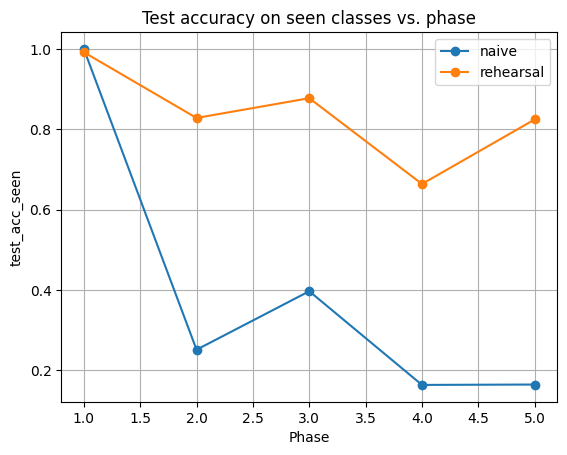

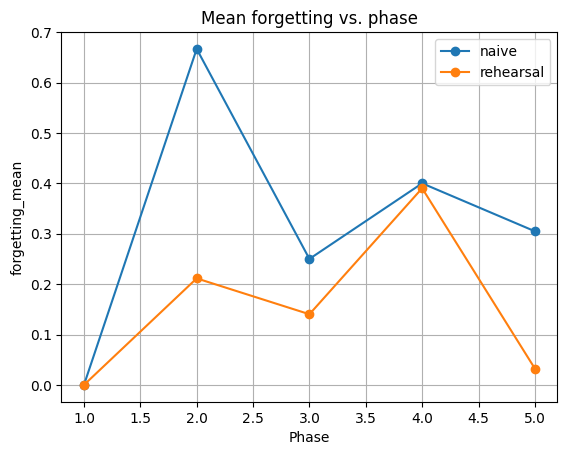

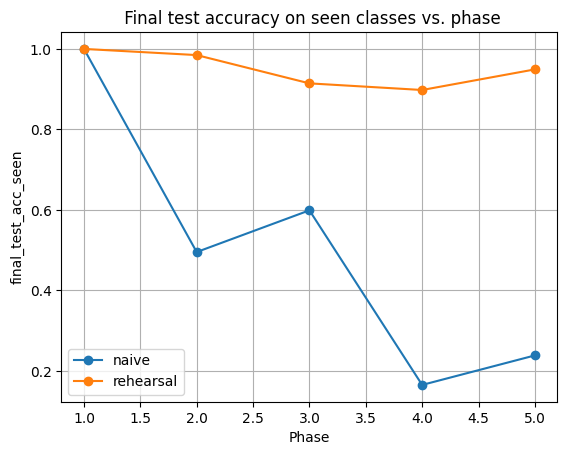

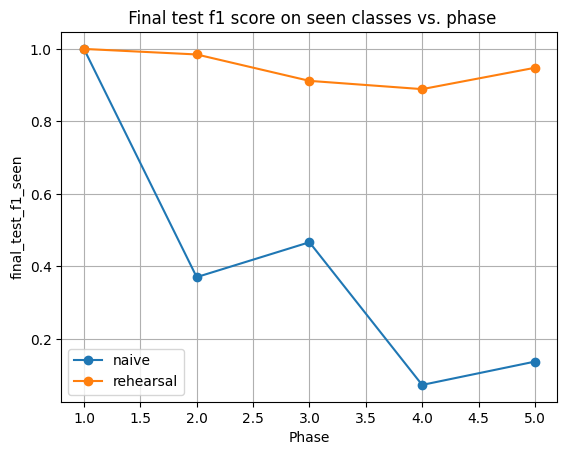

In [43]:
# this function visualizes how a metric evolves across phases. df -> dataframe containing continual learning results
def plot_metric(df, metric, title):
    for strat in df["strategy"].unique():  # iterating over both continual learning strategies (naive, rehearsal)
        sub = df[df["strategy"] == strat]   # selecting only the rows corresponding to the current strategy
        plt.plot(sub["phase"], sub[metric], marker = "o", label = strat)  # plotting the selected metric as a function of the learning phase
        # markers -> phase boundaries
    plt.xlabel("Phase")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metric(df_all, "test_acc_seen", "Test accuracy on seen classes vs. phase")  # plotting how test accuracy on seen classes evolves across phases
# -> used to assess knowledge accumulation over time
plot_metric(df_all, "forgetting_mean", "Mean forgetting vs. phase")  # plotting the average forgetting across classes as learning progresses
# -> used to quantify catastrophic forgetting

# added later
plot_metric(df_all, "final_test_acc_seen", " Final test accuracy on seen classes vs. phase")
plot_metric(df_all, "final_test_f1_seen", " Final test f1 score on seen classes vs. phase")


we can change some parameters and bring the rehearsal accuracy closer to upperboud accuracy (baseline). This can be done by:

increasing m_per_class (for example 100 or 200)

having more balanced data

having smaller learning rate

#19. Parameter Impact & Tuning

comparing memory size and model depth

In [44]:
param_rows = []  # empty list to store summary results for each experiment configuration

for model_name, model_cls in [("cnn1", SmallCNN1), ("cnn2", SmallCNN2)]:  # iterating over the two model architectures to compare
    for m in [0, 20, 50, 100]:   # iterating over different memory sizes per class
        if m == 0:   # no replay (naive strategy)
            df_tmp, _ = run_continual(model_cls, strategy = "naive", epochs_per_phase = 3)  # running continual learning without rehearsal
            strat = "naive"
        else:   # rehearsal continual learning
            # running continual learning with replay memory of size m per class
            df_tmp, _ = run_continual(model_cls, strategy = "rehearsal", m_per_class = m, epochs_per_phase = 3)
            strat = "rehearsal"


        last = df_tmp.iloc[-1]   # selecting results from the final learning phase
        param_rows.append({"model": model_name, "strategy": strat, "m_per_class": m, "final_acc_seen": float(last["test_acc_seen"]),
                           "final_forgetting": float(last["forgetting_mean"])})  # storing final accuracy and forgetting for this configuration

df_params = pd.DataFrame(param_rows).sort_values("final_acc_seen", ascending = False)  # creating dataframe & sort configurations by final accuracy
df_params

[naive] Phase 1 Ep 1 | loss = 1.7394 | val_acc_seen = 0.0082
[naive] Phase 1 Ep 2 | loss = 1.3685 | val_acc_seen = 0.3361
[naive] Phase 1 Ep 3 | loss = 1.1545 | val_acc_seen = 0.7131
==> Phase 1 done | acc_seen = 0.7131 | forgetting = 0.0000

[naive] Phase 2 Ep 1 | loss = 2.1367 | val_acc_seen = 0.1963
[naive] Phase 2 Ep 2 | loss = 1.9596 | val_acc_seen = 0.2577
[naive] Phase 2 Ep 3 | loss = 1.8246 | val_acc_seen = 0.2577
==> Phase 2 done | acc_seen = 0.2577 | forgetting = 0.6667

[naive] Phase 3 Ep 1 | loss = 1.9172 | val_acc_seen = 0.0343
[naive] Phase 3 Ep 2 | loss = 1.8140 | val_acc_seen = 0.0049
[naive] Phase 3 Ep 3 | loss = 1.7266 | val_acc_seen = 0.0147
==> Phase 3 done | acc_seen = 0.0147 | forgetting = 0.7561

[naive] Phase 4 Ep 1 | loss = 2.4988 | val_acc_seen = 0.0697
[naive] Phase 4 Ep 2 | loss = 2.3816 | val_acc_seen = 0.0943
[naive] Phase 4 Ep 3 | loss = 2.2728 | val_acc_seen = 0.1352
==> Phase 4 done | acc_seen = 0.1352 | forgetting = 0.6049

[naive] Phase 5 Ep 1 | loss 

,model,strategy,m_per_class,final_acc_seen,final_forgetting
7,cnn2,rehearsal,100,0.838596,0.016260
6,cnn2,rehearsal,50,0.828070,0.032520
5,cnn2,rehearsal,20,0.778947,0.085366
2,cnn1,rehearsal,50,0.736842,0.044715
3,cnn1,rehearsal,100,0.568421,0.056911
1,cnn1,rehearsal,20,0.442105,0.199187
4,cnn2,naive,0,0.284211,0.330894
0,cnn1,naive,0,0.042105,0.589431


compraing different learning rates

[naive] Phase 1 Ep 1 | loss = 2.1155 | val_acc_seen = 0.0000
[naive] Phase 1 Ep 2 | loss = 2.0642 | val_acc_seen = 0.0000
[naive] Phase 1 Ep 3 | loss = 2.0140 | val_acc_seen = 0.0000
==> Phase 1 done | acc_seen = 0.0000 | forgetting = 0.0000

[naive] Phase 2 Ep 1 | loss = 2.1773 | val_acc_seen = 0.0000
[naive] Phase 2 Ep 2 | loss = 2.1610 | val_acc_seen = 0.0184
[naive] Phase 2 Ep 3 | loss = 2.1435 | val_acc_seen = 0.0491
==> Phase 2 done | acc_seen = 0.0491 | forgetting = 0.0000

[naive] Phase 3 Ep 1 | loss = 1.8044 | val_acc_seen = 0.2353
[naive] Phase 3 Ep 2 | loss = 1.7940 | val_acc_seen = 0.2451
[naive] Phase 3 Ep 3 | loss = 1.7840 | val_acc_seen = 0.0392
==> Phase 3 done | acc_seen = 0.0392 | forgetting = 0.0000

[naive] Phase 4 Ep 1 | loss = 1.8971 | val_acc_seen = 0.0000
[naive] Phase 4 Ep 2 | loss = 1.8867 | val_acc_seen = 0.0000
[naive] Phase 4 Ep 3 | loss = 1.8763 | val_acc_seen = 0.0000
==> Phase 4 done | acc_seen = 0.0000 | forgetting = 0.0390

[naive] Phase 5 Ep 1 | loss 

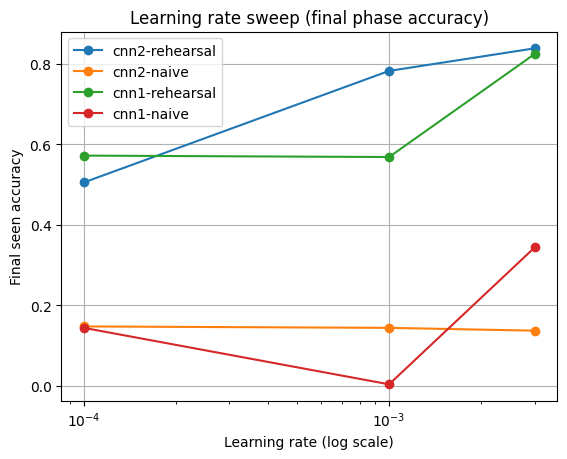

In [45]:
# this part is almost the copy of previous cell but different learning rates are added for comparison. I kept it small for speed

lr_rows = []

lr_list = [1e-4, 1e-3, 3e-3]
memory_list = [0, 50]
model_list = [("cnn1", SmallCNN1), ("cnn2", SmallCNN2)]

for model_name, model_cls in model_list:
    for lr in lr_list:
        for m in memory_list:
            if m == 0:
                strat = "naive"
                df_tmp, _ = run_continual(model_cls, strategy="naive", lr=lr, epochs_per_phase=3)
            else:
                strat = "rehearsal"
                df_tmp, _ = run_continual(model_cls, strategy="rehearsal", m_per_class=m, lr=lr, epochs_per_phase=3)

            last = df_tmp.iloc[-1]
            lr_rows.append({
                "model": model_name,
                "strategy": strat,
                "m_per_class": m,
                "lr": lr,
                "final_acc_seen": float(last["test_acc_seen"]),
                "final_forgetting": float(last["forgetting_mean"])
            })

df_lr = pd.DataFrame(lr_rows).sort_values("final_acc_seen", ascending=False)
df_lr

# plotting how the final accuracy on seen classes changes with learning rate, separately for each model and training strategy
for model_name in df_lr["model"].unique():  # loopin over different architectures
    sub_m = df_lr[df_lr["model"] == model_name]  # experiments run with this model, but still multiple strategies and learning rates
    for strat in sub_m["strategy"].unique():  # lopoing over strategies for that model
        sub = sub_m[sub_m["strategy"] == strat]  # filtering by strategy. now sub contains sexperiments with same model &strategy but different learning rates
        g = sub.groupby("lr")["final_acc_seen"].mean().reset_index()  # grouping by learning rate cuz we may have multiple runs with the same lr (different seeds, repititions)
        # so I group and average so I will have one clean point per lr
        plt.plot(g["lr"], g["final_acc_seen"], marker="o", label=f"{model_name}-{strat}")
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Final seen accuracy")
plt.title("Learning rate sweep (final phase accuracy)")
plt.legend()
plt.grid(True)
plt.show()



Comparing Baseline vs. Continual (naive & rehearsal) for CNN1 and CNN2

[naive] Phase 1 Ep 1 | loss = 1.7621 | val_acc_seen = 0.5902
[naive] Phase 1 Ep 2 | loss = 1.4024 | val_acc_seen = 1.0000
[naive] Phase 1 Ep 3 | loss = 1.1682 | val_acc_seen = 0.9836
[naive] Phase 1 Ep 4 | loss = 1.0062 | val_acc_seen = 0.9836
[naive] Phase 1 Ep 5 | loss = 0.8730 | val_acc_seen = 0.9836
==> Phase 1 done | acc_seen = 0.9836 | forgetting = 0.0000

[naive] Phase 2 Ep 1 | loss = 2.2598 | val_acc_seen = 0.5031
[naive] Phase 2 Ep 2 | loss = 2.0648 | val_acc_seen = 0.5031
[naive] Phase 2 Ep 3 | loss = 1.9159 | val_acc_seen = 0.2515
[naive] Phase 2 Ep 4 | loss = 1.7779 | val_acc_seen = 0.2515
[naive] Phase 2 Ep 5 | loss = 1.6685 | val_acc_seen = 0.2515
==> Phase 2 done | acc_seen = 0.2515 | forgetting = 0.6667

[naive] Phase 3 Ep 1 | loss = 2.7702 | val_acc_seen = 0.2010
[naive] Phase 3 Ep 2 | loss = 2.6538 | val_acc_seen = 0.4020
[naive] Phase 3 Ep 3 | loss = 2.5474 | val_acc_seen = 0.4020
[naive] Phase 3 Ep 4 | loss = 2.4444 | val_acc_seen = 0.4020
[naive] Phase 3 Ep 5 | los

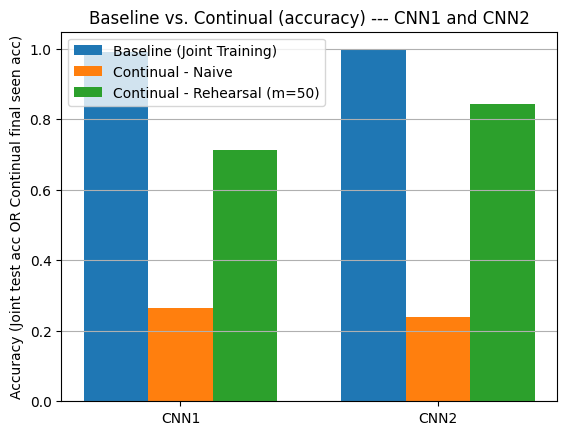

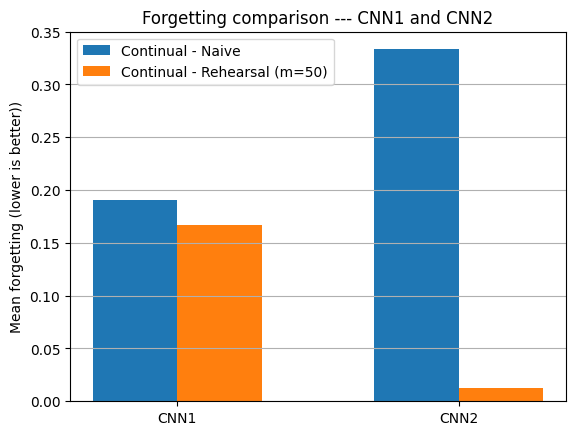

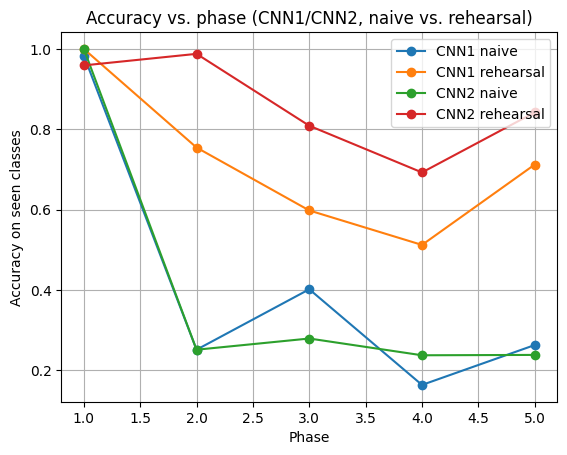

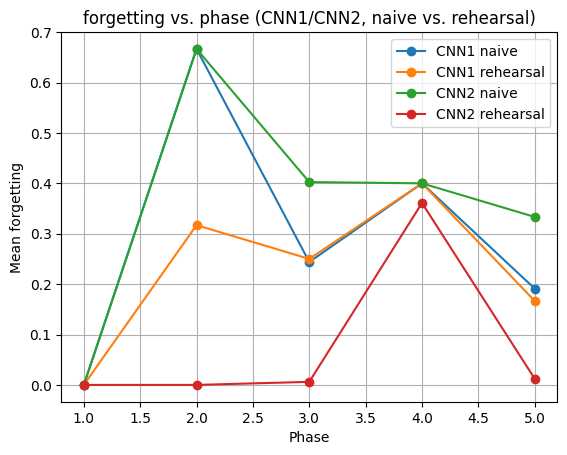

In [49]:
LR = 1e-3
EPOCHS_PER_PHASE = 5
M_PER_CLASS = 50

# run continual for CNN1 -> both naive and rehearsal
df_cnn1_naive, _ = run_continual(SmallCNN1, strategy = "naive", lr = LR, epochs_per_phase = EPOCHS_PER_PHASE)
df_cnn1_reh, _ = run_continual(SmallCNN1, strategy = "rehearsal", m_per_class = M_PER_CLASS, lr = LR, epochs_per_phase = EPOCHS_PER_PHASE)

# extracting final phase results
last_cnn1_naive = df_cnn1_naive.iloc[-1]  # .iloc[-1] -> selects the last phase -> final performance after all tasks
last_cnn1_reh = df_cnn1_reh.iloc[-1]

# the same for CNN2
df_cnn2_naive, _ = run_continual(SmallCNN2, strategy = "naive", lr = LR, epochs_per_phase = EPOCHS_PER_PHASE)
df_cnn2_reh, _ = run_continual(SmallCNN2, strategy = "rehearsal", m_per_class = M_PER_CLASS, lr = LR, epochs_per_phase = EPOCHS_PER_PHASE)

last_cnn2_naive = df_cnn2_naive.iloc[-1]
last_cnn2_reh = df_cnn2_reh.iloc[-1]


# building a clean table to unify baseline and continual results
# macro_f1: balanced class performance  # forgetting: average forgetting (NaN for baseline)
rows = [
    # CNN1 group
    {"group":"CNN1", "method":"Baseline (Joint Training)", "accuracy": test_acc, "macro_f1": test_f1, "forgetting":np.nan},
    {"group":"CNN1", "method":"Continual - Naive", "accuracy":float(last_cnn1_naive["test_acc_seen"]), "macro_f1":float(last_cnn1_naive["test_f1_seen"]), "forgetting":float(last_cnn1_naive["forgetting_mean"])},
    {"group":"CNN1", "method":f"Continual - Rehearsal (m={M_PER_CLASS})", "accuracy":float(last_cnn1_reh["test_acc_seen"]), "macro_f1":float(last_cnn1_reh["test_f1_seen"]), "forgetting":float(last_cnn1_reh["forgetting_mean"])},

    # CNN2 group
    {"group":"CNN2", "method":"Baseline (Joint Training)", "accuracy": test_acc2, "macro_f1": test_f12, "forgetting":np.nan},
    {"group":"CNN2", "method":"Continual - Naive", "accuracy":float(last_cnn2_naive["test_acc_seen"]), "macro_f1":float(last_cnn2_naive["test_f1_seen"]), "forgetting":float(last_cnn2_naive["forgetting_mean"])},
    {"group":"CNN2", "method":f"Continual - Rehearsal (m={M_PER_CLASS})", "accuracy":float(last_cnn2_reh["test_acc_seen"]), "macro_f1":float(last_cnn2_reh["test_f1_seen"]), "forgetting":float(last_cnn2_reh["forgetting_mean"])},
]

df_model_compare = pd.DataFrame(rows)  # main quantitative comparison artifact

print("=== TABLE: Baseline vc. Continual (per model) ===")
df_model_compare


# accuracy bar plot (baseline vs continual) -> how much accuracy do we lose when switching from joint training to continual learning, and how much rehearsal recovers it?
plt.figure()
groups = ["CNN1", "CNN2"]  # the x axis
method_order = ["Baseline (Joint Training)", "Continual - Naive", f"Continual - Rehearsal (m={M_PER_CLASS})"]

x = np.arange(len(groups))
width = 0.25  # bar width -> small -> to avoid overlapping bars

for i, meth in enumerate(method_order):  # looping over methods. here the bar height is determined
    vals = []  # after this loop vals will be like: vals = [accuracy_for_CNN1, accuracy_for_CNN2]
    for g in groups: # collecting the accuracy for CNN1 and CNN2
        vals.append(df_model_compare[(df_model_compare["group"] == g) & (df_model_compare["method"] == meth)]["accuracy"].values[0])
    plt.bar(x + (i-1) * width, vals, width = width, label = meth)   # bar positioning   # x -> group centers: [0, 1]  # i -> which method we are plotting
    # (i - 1) -> shifts bars left or right

plt.xticks(x, groups)
plt.ylabel("Accuracy (Joint test acc OR Continual final seen acc)")
plt.title("Baseline vs. Continual (accuracy) --- CNN1 and CNN2")
plt.legend()
plt.grid(True, axis ="y")
plt.show()


# forgetting bar plot -> only meaningful for continual -> how forgetting accumulates over time -> the codes are almost the same as above
plt.figure()
methods_forget = ["Continual - Naive", f"Continual - Rehearsal (m={M_PER_CLASS})"]
width = 0.3

for i, meth in enumerate(methods_forget):
    vals = []
    for g in groups:
        vals.append(df_model_compare[(df_model_compare["group"] == g) & (df_model_compare["method"] == meth)]["forgetting"].values[0])
    plt.bar(x + (i-0.5) * width, vals, width = width, label = meth)


plt.xticks(x, groups)
plt.ylabel("Mean forgetting (lower is better))")
plt.title("Forgetting comparison --- CNN1 and CNN2")
plt.legend()
plt.grid(True, axis ="y")
plt.show()


# phase curves (accuracy & forgetting) per model
plt.figure()
plt.plot(df_cnn1_naive["phase"], df_cnn1_naive["test_acc_seen"], marker = "o", label = "CNN1 naive")
plt.plot(df_cnn1_reh["phase"], df_cnn1_reh["test_acc_seen"], marker = "o", label = "CNN1 rehearsal")
plt.plot(df_cnn2_naive["phase"], df_cnn2_naive["test_acc_seen"], marker = "o", label = "CNN2 naive")
plt.plot(df_cnn2_reh["phase"], df_cnn2_reh["test_acc_seen"], marker = "o", label = "CNN2 rehearsal")
plt.xlabel("Phase")
plt.ylabel("Accuracy on seen classes")
plt.title("Accuracy vs. phase (CNN1/CNN2, naive vs. rehearsal)")
plt.legend()
plt.grid(True)
plt.show()



plt.figure()
plt.plot(df_cnn1_naive["phase"], df_cnn1_naive["forgetting_mean"], marker = "o", label = "CNN1 naive")
plt.plot(df_cnn1_reh["phase"], df_cnn1_reh["forgetting_mean"], marker = "o", label = "CNN1 rehearsal")
plt.plot(df_cnn2_naive["phase"], df_cnn2_naive["forgetting_mean"], marker = "o", label = "CNN2 naive")
plt.plot(df_cnn2_reh["phase"], df_cnn2_reh["forgetting_mean"], marker = "o", label = "CNN2 rehearsal")
plt.xlabel("Phase")
plt.ylabel("Mean forgetting")
plt.title("forgetting vs. phase (CNN1/CNN2, naive vs. rehearsal)")
plt.legend()
plt.grid(True)
plt.show()

